# L20 · 🎨 分解图谱 — LU / QR / SVD 三种分解的几何意义对比

> 来自《The Art of Linear Algebra》。把矩阵拆成几块的乘积：

`A=LU`(消元) · `A=QR`(正交化) · `S=QΛQᵀ`(对称特征) · `A=UΣVᵀ`(SVD)。

**学习目标**
1. 用 `laviz` 的 `show_factorization` 把 LU 分解画成「下三角消元 × 上三角阶梯」的几何步骤
2. 观察 QR 分解中 Q 的正交性（`QᵀQ = I`）和 R 的上三角结构，理解 Gram-Schmidt 正交化含义
3. 对比对称矩阵谱定理 `S = QΛQᵀ` 与一般矩阵 SVD `A = UΣVᵀ` 的几何结构差异
4. 通过奇异值序列判断矩阵有效秩：保留前 k 个奇异值可重建主要信息，丢掉小奇异值即滤噪
5. 理解 Aurora mel 频谱矩阵的 SVD 低秩近似：最小的奇异值对应背景噪声分量

**为什么对 Aurora 重要**：MFCC 提取流水线里的 Mel 滤波器矩阵可做 SVD 降维，QR 分解用于数值稳定的最小二乘；理解几何含义，代码调参时才不会乱猜。

← **上一课**　[L19 · 矩阵变换图解](L19_visual_multiply.ipynb)

> 上节课学习了 **矩阵变换图解**：旋转、缩放、剪切的动态视觉演示。  
> 本课将探讨 **分解图谱**。

## 本课剧情：让空间动起来

矩阵分解的思路是把一个复杂变换拆成几步简单变换的乘积，每步都有清晰的几何意义。LU 是消元的矩阵语言，QR 把任意基正交化，SVD 把任意矩阵写成旋转-拉伸-旋转三步，适用于任何形状的矩阵。这节通过图形展示每种分解在坐标系上实际做了什么。

In [1]:
import numpy as np
from aurora.laviz import style, show_factorization, heatmap
style(); print('就绪')

就绪


## 符号入口：先看形状，再看运算

分解式中每个因子都是矩阵，理解分解就是依次理解各因子的几何效果。LU 中 L 做行剪切、U 做上三角缩放；QR 中 Q 是旋转、R 是上三角拉伸；SVD 中 U 和 V 是旋转、Σ 是轴向拉伸。

## 动手观察：线代对象先看形状，再看意义

运行下面的代码，注意各因子的 shape：L 和 U 为何都是方阵，Q 的列为何两两正交，SVD 中 U、Σ、Vᵀ 的维度如何与原矩阵 A 的行列数对应。

In [ ]:
import numpy as np

# QR 分解：A = Q R（Q 正交，R 上三角）
A = np.array([[1.,2.],[3.,4.],[5.,6.]])
Q, R = np.linalg.qr(A)
print('Q（正交列）=\n', np.round(Q, 4))
print('R（上三角）=\n', np.round(R, 4))
print('Q^T @ Q =\n', np.round(Q.T @ Q, 10))  # 应为 I
print('重建误差 =', np.max(np.abs(A - Q @ R)))


## 代码实验：遍历几个向量（vector），观察矩阵如何改变它们

对同一个矩阵 A 输入几组测试向量，观察 A 把它们分别旋转和拉伸了多少——SVD 中 Σ 的对角值决定了每个方向上的拉伸幅度。

In [ ]:
import numpy as np

# 同一矩阵三种分解的比较
A = np.array([[2.,1.,1.],[4.,3.,3.],[8.,7.,9.]])
# LU
# LU 分解（Doolittle，无主元选取，纯 numpy）
def _lu(A):
    n = len(A)
    L, U = np.eye(n), A.copy().astype(float)
    for j in range(n):
        for i in range(j+1, n):
            L[i,j] = U[i,j] / U[j,j]
            U[i] -= L[i,j] * U[j]
    return L, U
L, U = _lu(A)
print(f'LU: L对角线={np.round(np.diag(L),4)}, U对角线={np.round(np.diag(U),4)}')
# QR
Q, R = np.linalg.qr(A)
print(f'QR: R对角线={np.round(np.diag(R),4)}')
# SVD
s = np.linalg.svd(A, compute_uv=False)
print(f'SVD: 奇异值={np.round(s,4)}')
print(f'rank={np.linalg.matrix_rank(A)}')


## 1. A = LU（高斯消元（Gaussian elimination）的矩阵形式）

下三角 L × 上三角 U。对应你在 `L15` 学的消元。

**为什么这样设计**：这节选择用 laviz 图而非纯公式，因为每个因子都有对应的几何动作，图比符号更直接。以 SVD 为例：A=UΣVᵀ 读成三步——Vᵀ 把输入旋转到矩阵的主方向，Σ 沿这些方向按奇异值（singular value）大小拉伸，U 再旋转到输出空间；laviz 把三步叠加显示，分解的结构立刻可读。LU 同理：L 的次对角元素是消元乘数（行剪切），U 是阶梯形上三角——两步合起来完整记录了高斯消元的每一行操作。

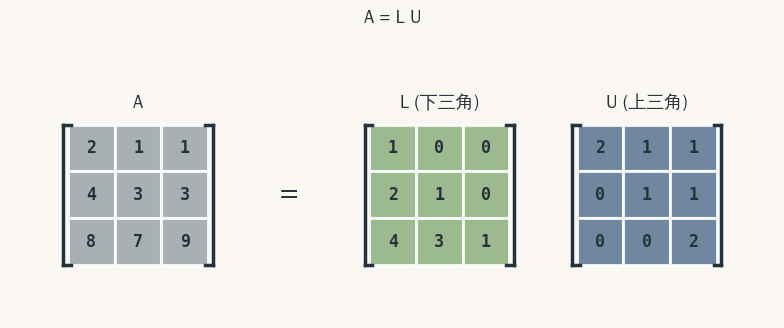

In [2]:
A = np.array([[2.,1,1],[4,3,3],[8,7,9]])
# 用 _lu(A) 算法计算 L, U（与 L15 的行变换同源）
L, U = _lu(A)
assert np.allclose(L @ U, A)
show_factorization(A, [L, U], ['L (下三角)', 'U (上三角)'],
                   modes=['#8AB17D', '#577590'], title='A = L U');

## 2. A = QR（Gram-Schmidt 正交化）

正交矩阵（orthogonal matrix） Q × 上三角 R，且 `QᵀQ = I`。

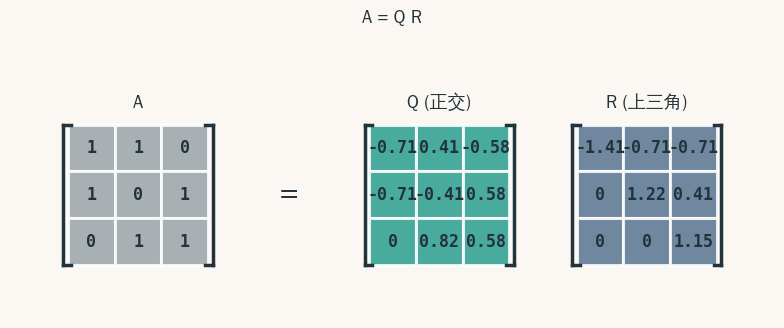

In [3]:
A = np.array([[1.,1,0],[1,0,1],[0,1,1]])
Q, R = np.linalg.qr(A)
assert np.allclose(Q @ R, A) and np.allclose(Q.T @ Q, np.eye(3))
show_factorization(A, [Q, R], ['Q (正交)', 'R (上三角)'],
                   modes=['#2A9D8F', '#577590'], title='A = Q R');

## 3. S = QΛQᵀ（对称矩阵（symmetric matrix）的特征分解（eigendecomposition） / 谱定理（spectral theorem））

对称矩阵 → 正交的特征向量 Q + 对角的特征值 Λ。对应你在 `L17` 学的对角化（diagonalization）。

/home/user/AURORA/notebooks/prep_linear_algebra/laviz.py:259: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) WenQuanYi Zen Hei.
  fig.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:100: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) WenQuanYi Zen Hei.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


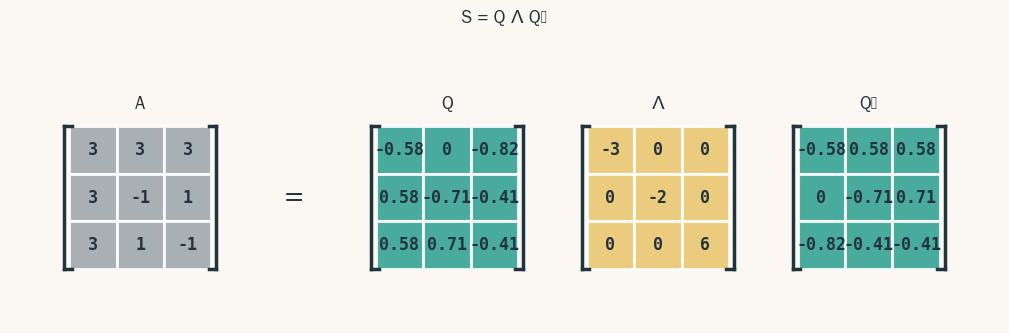

In [4]:
S = np.array([[3.,3,3],[3,-1,1],[3,1,-1]])    # L17 的同一个例子
vals, Q = np.linalg.eigh(S)
Lam = np.diag(vals)
assert np.allclose(Q @ Lam @ Q.T, S)
show_factorization(S, [Q, Lam, Q.T], ['Q', 'Λ', 'Qᵀ'],
                   modes=['#2A9D8F', '#E9C46A', '#2A9D8F'], title='S = Q Λ Qᵀ');

## 4. A = UΣVᵀ（奇异值分解（singular value decomposition，SVD） SVD，任意矩阵都有）

左奇异向量 U + 奇异值 Σ + 右奇异向量 Vᵀ。`L14` 的 SVD，这里画出来。

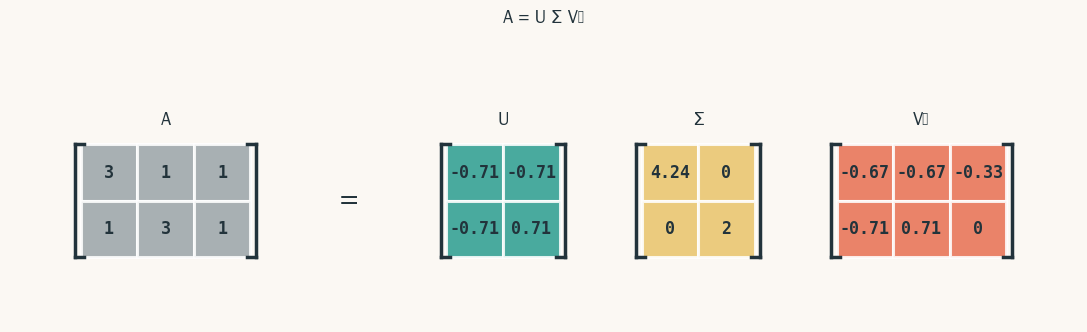

In [5]:
A = np.array([[3.,1,1],[1,3,1]])
U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sig = np.diag(s)
assert np.allclose(U @ Sig @ Vt, A)
show_factorization(A, [U, Sig, Vt], ['U', 'Σ', 'Vᵀ'],
                   modes=['#2A9D8F', '#E9C46A', '#E76F51'], title='A = U Σ Vᵀ');

**🔗 Aurora**：SVD 用于推荐(矩阵分解)、embedding 降维、LoRA；对称特征分解 = PCA。下一节 `L21`：把这些"矩阵视角"对准 Aurora 的音频核心。

In [ ]:
import numpy as np

# 参数实验：不同条件数的矩阵，各分解的数值稳定性
for cond_target in [1, 10, 1000]:
    s_vals = np.array([float(cond_target), 1.0])
    A = np.array([[s_vals[0],0.],[0.,s_vals[1]]])
    kappa = np.linalg.cond(A)
    _, r = np.linalg.qr(A)
    print(f'κ={kappa:.0f}  QR R 对角={np.round(np.diag(r),4)}')
print('→ 条件数越大，R 的对角线元素差距越大，方程组求解越不稳定。')


## 参数实验：只改一个旋钮

在 SVD 图里，把矩阵从满秩改成秩1（如 `np.outer([1,2],[3,4])`），观察 Σ 中只有第一个奇异值非零，对应只保留一个方向的信息。

## 5. ✏️ 练习：用 SVD 计算数值秩 `rank_from_svd(A)`

`np.linalg.matrix_rank` 的本质：做 SVD，数有多少个奇异值 > threshold。
自己实现一遍——不准调用 `np.linalg.matrix_rank`。

**推理路线**：
1. `U, S, Vt = np.linalg.svd(A)`
2. 设门限 `t = threshold * S[0]`（相对最大奇异值）
3. 返回 `S > t` 的个数

In [ ]:
import numpy as np

def rank_from_svd(A, threshold=1e-10):
    """用 SVD 计算矩阵数值秩（不调用 np.linalg.matrix_rank）"""
    A = np.asarray(A, float)
    # ✏️ TODO: svd → 数奇异值 > threshold * S[0] 的个数
    raise NotImplementedError('请实现 rank_from_svd')

# 验证
try:
    # 满秩矩阵
    A_full = np.array([[1.,2.],[3.,4.]])
    assert rank_from_svd(A_full) == 2, '满秩 2×2 应返回秩 2'

    # 秩亏矩阵（行相关）
    A_rank1 = np.outer([1., 2., 3.], [4., 5., 6.])  # 外积 → 秩 1
    assert rank_from_svd(A_rank1) == 1, f'秩1矩阵应返回 1，得到 {rank_from_svd(A_rank1)}'

    # 矩形矩阵
    A_rect = np.array([[1.,0.,0.],[0.,1.,0.]])       # 2×3，秩 2
    assert rank_from_svd(A_rect) == 2, '矩形满行秩矩阵应返回 2'

    # 与 numpy 对比
    rng = np.random.default_rng(42)
    A_rand = rng.standard_normal((5, 4))
    assert rank_from_svd(A_rand) == np.linalg.matrix_rank(A_rand), '与 numpy 结果不一致'

    print('✅ 通过：rank_from_svd 在满秩、秩亏、矩形四种情形均正确')
except NotImplementedError:
    print('⬆️  先把 rank_from_svd 实现完再运行')


## 本课收束

现在可以用 `np.linalg.svd(A)` 拿到 U、Σ、Vᵀ，用奇异值序列判断矩阵的有效秩和各方向的信息量。这套分解方式直接对应 Aurora 中 mel 频谱矩阵的低秩近似：保留前 k 个奇异值即可重建主要频谱结构，丢掉的部分是噪声。下一节 `L21` 将这套矩阵视角对准 Aurora 的音频核心，看实际频谱数据在 SVD 下的奇异值分布。

---

→ **下一课**　[L21 · 矩阵即滤波](L21_aurora_matrices.ipynb)

> 下节课将学习 **矩阵即滤波**：DFT 矩阵 / Mel 矩阵：音频处理 = 矩阵乘法。